LSTM for MNIST Digit Classification

# 1. Prepare the environment

In [1]:
# List all NVIDIA GPUs as available in this computer (or Colab's session)
!nvidia-smi -L

GPU 0: NVIDIA A100-SXM4-40GB (UUID: GPU-448d636d-e64b-8cbe-fcff-de4c592c9eed)


In [2]:
import sys
print( f"Python {sys.version}\n" )

import numpy as np
print( f"NumPy {np.__version__}\n" )

import matplotlib.pyplot as plt
%matplotlib inline

# https://keras.io/getting_started/
# The backend must be configured before importing Keras, and the backend cannot be changed after the package has been imported.
import os
os.environ["KERAS_BACKEND"] = "torch"  # "jax", "tensorflow"

import keras
print(f"Keras {keras.__version__}")
print(f"|- Keras backend = {keras.backend.backend()}")
print(f"|- Keras backend image data format = {keras.backend.image_data_format()}\n")

import torch
print( f"PyTorch {torch.__version__}" )

# Get all available accelerators such as CUDA, MPS, MTIA, or XPU
num_accelerators = torch.accelerator.device_count()

if (num_accelerators <= 0):
    print("|- No hardware accelerators found. Using CPU only.")
else:
    print(f"|- PyTorch detected {num_accelerators} hardware accelerator(s)")
    print(f"|- PyTorch detected '{torch.accelerator.current_accelerator().type.upper()}' as the current accelerator")

    # Check cuda availability
    if torch.cuda.is_available():
        num_gpus = torch.cuda.device_count()
        print(f"|- PyTorch detected {num_gpus} CUDA GPU(s):")
    for i in range(num_gpus):
        print(f"   |- CUDA GPU {i}: {torch.cuda.get_device_name(i)}")

Python 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]

NumPy 2.0.2

Keras 3.10.0
|- Keras backend = torch
|- Keras backend image data format = channels_last

PyTorch 2.8.0+cu126
|- PyTorch detected 1 hardware accelerator(s)
|- PyTorch detected 'CUDA' as the current accelerator
|- PyTorch detected 1 CUDA GPU(s):
   |- CUDA GPU 0: NVIDIA A100-SXM4-40GB


In [3]:
# Set fixed seeding values for reproducability during experiments
# Skip this cell if random initialization (with varied results) is needed

# https://keras.io/examples/keras_recipes/reproducibility_recipes/
# Set the seed using keras.utils.set_random_seed. This will set:
# 1) `numpy` seed
# 2) backend random seed
# 3) `python` random seed
#keras.utils.set_random_seed(1234)

# 2. Prepare the MNIST Dataset

In [4]:
# Load the MNIST dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# Inspect the dataset
print( f"x_train: type={type(x_train)} , dtype={x_train.dtype} , shape={x_train.shape} , min={x_train.min(axis=None)} , max={x_train.max(axis=None)}" )
print( f"y_train: type={type(y_train)} , dtype={y_train.dtype} , shape={y_train.shape} , min={min(y_train)} , max={max(y_train)} " )
print( f"x_test: type={type(x_test)} , dtype={x_test.dtype} , shape={x_test.shape} , min={x_test.min(axis=None)} , max={x_test.max(axis=None)}" )
print( f"y_test: type={type(y_test)} , dtype={y_test.dtype} , shape={y_test.shape} , min={min(y_test)} , max={max(y_test)}" )

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train: type=<class 'numpy.ndarray'> , dtype=uint8 , shape=(60000, 28, 28) , min=0 , max=255
y_train: type=<class 'numpy.ndarray'> , dtype=uint8 , shape=(60000,) , min=0 , max=9 
x_test: type=<class 'numpy.ndarray'> , dtype=uint8 , shape=(10000, 28, 28) , min=0 , max=255
y_test: type=<class 'numpy.ndarray'> , dtype=uint8 , shape=(10000,) , min=0 , max=9


In [5]:
# Convert each pixel from unsigned int 8-bit (0-255) data type to 32-bit floating point data type
x_train = x_train.astype( np.float32 )
x_test = x_test.astype( np.float32 )

# Input normalization from 0-255 to 0.0-1.0
x_train /= 255
x_test /= 255

In [6]:
# Convert the integer label (0-9) to a one-hot encoding vector
y_train_1hot = keras.utils.to_categorical( y_train, 10 )
y_test_1hot = keras.utils.to_categorical( y_test, 10 )

# Inspect the encoded data
print( f"y_train: original.shape = {y_train.shape}, one-hot.shape = {y_train_1hot.shape}" )
print( f"y_test: original.shape = {y_test.shape}, one-hot.shape = {y_test_1hot.shape}\n" )

# Show the first 5 data for comparison
for i in range(5):
    print( f"y_train[{i}]: original = {y_train[i]} => one-hot = {y_train_1hot[i]}" )

y_train: original.shape = (60000,), one-hot.shape = (60000, 10)
y_test: original.shape = (10000,), one-hot.shape = (10000, 10)

y_train[0]: original = 5 => one-hot = [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
y_train[1]: original = 0 => one-hot = [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
y_train[2]: original = 4 => one-hot = [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
y_train[3]: original = 1 => one-hot = [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
y_train[4]: original = 9 => one-hot = [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


# 3. Create a LSTM model



In [7]:
model = keras.models.Sequential()

# Input layer ( time_steps=28, input_dim=28
model.add( keras.Input( (28,28,), name='input' ) )

# LSTM layer
model.add( keras.layers.LSTM( units=50, activation='relu' ) )

# Output layer
model.add( keras.layers.Dense( 1024, activation='relu' ) )
model.add( keras.layers.Dropout(0.5) )
model.add( keras.layers.Dense( 10, activation='softmax' ) )

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        15,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │        52,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │        10,250 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,274 (305.76 KB)

 Trainable params: 78,274 (305.76 KB)

 Non-trainable params: 0 (0.00 B)

# 4. Compile and train the model

In [8]:
# Compile the model
model.compile( loss="categorical_crossentropy", optimizer="adam", metrics=["acc"] )

In [9]:
hist = model.fit( x_train, y_train_1hot,
                  validation_split=0.2,
                  batch_size=128, epochs=20,
                  verbose=1,
            )

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - acc: 0.5150 - loss: 1.3951 - val_acc: 0.8960 - val_loss: 0.3068
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - acc: 0.9065 - loss: 0.2960 - val_acc: 0.9452 - val_loss: 0.1773
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 18s 47ms/step - acc: 0.9394 - loss: 0.1890 - val_acc: 0.9553 - val_loss: 0.1497
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - acc: 0.9541 - loss: 0.1480 - val_acc: 0.9633 - val_loss: 0.1217
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - acc: 0.9626 - loss: 0.1211 - val_acc: 0.9683 - val_loss: 0.1075
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - acc: 0.9640 - loss: 0.1125 - val_acc: 0.9706 - val_loss: 0.0971
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - acc: 0.9709 - loss: 0.0969 - val_acc: 0.9692 - val_loss: 0.1066
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - acc: 0.9703 - loss: 0.0942 - val_acc: 0.9749 - val_loss: 0.0826
Epoch 9/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 

In [10]:
hist.history.keys()

dict_keys(['acc', 'loss', 'val_acc', 'val_loss'])

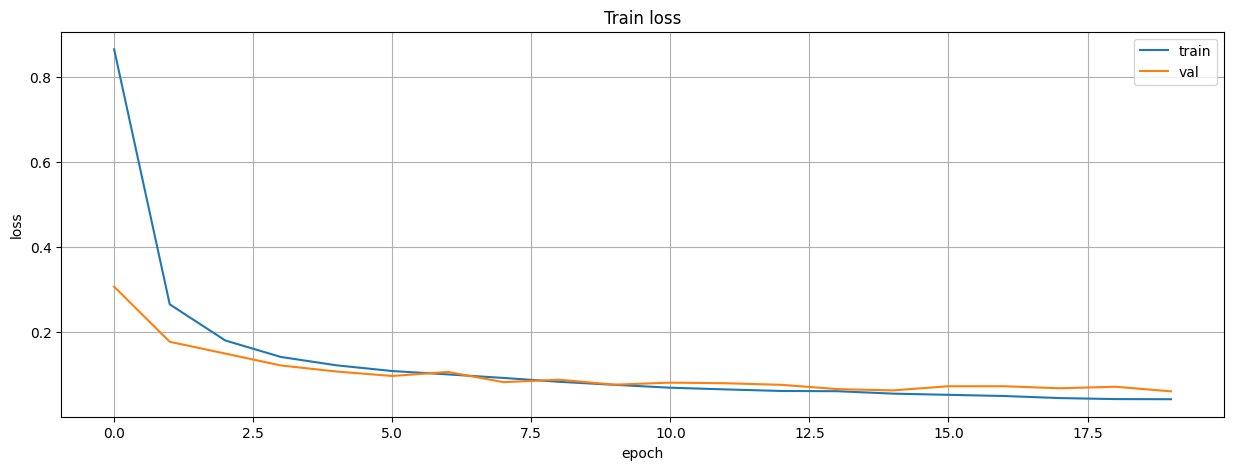

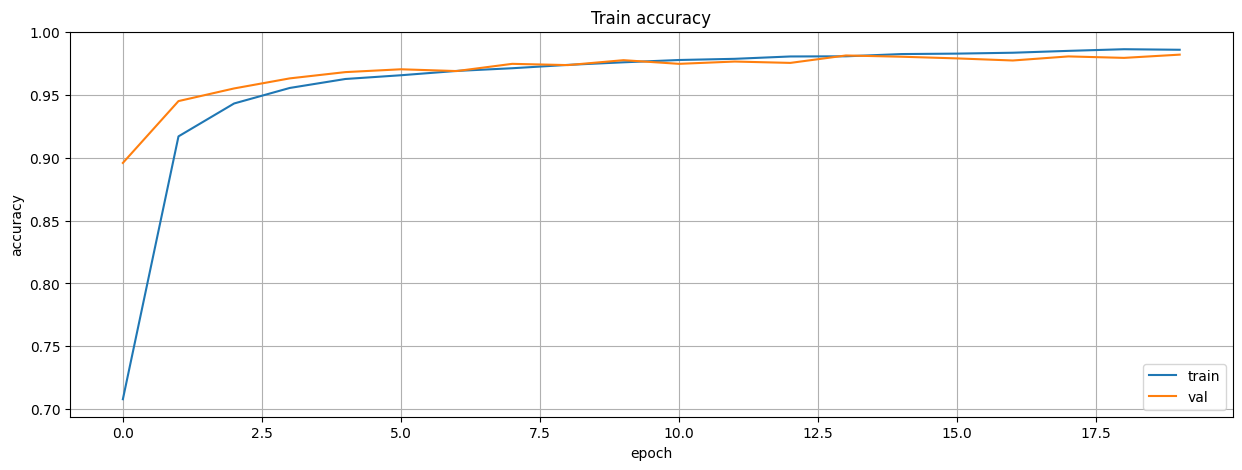

In [11]:
# Summarize history for loss
plt.figure(figsize=(15,5))
plt.plot(hist.history['loss'])
plt.plot(hist.history['val_loss'])
plt.title('Train loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.grid()
plt.show()

# Summarize history for accuracy
plt.figure(figsize=(15,5))
plt.plot(hist.history['acc'])
plt.plot(hist.history['val_acc'])
plt.title('Train accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='lower right')
plt.grid()
plt.show()

# 5. Evaluate the model

In [12]:
score = model.evaluate( x_test, y_test_1hot, verbose=0, return_dict=True )

print( "Test results (model from the last epoch):", score )

Test results (model from the last epoch): {'acc': 0.9812999963760376, 'loss': 0.06319284439086914}


# 6. Inference

y_preds:
>> Type: <class 'numpy.ndarray'>
>> Shape: (20, 10)



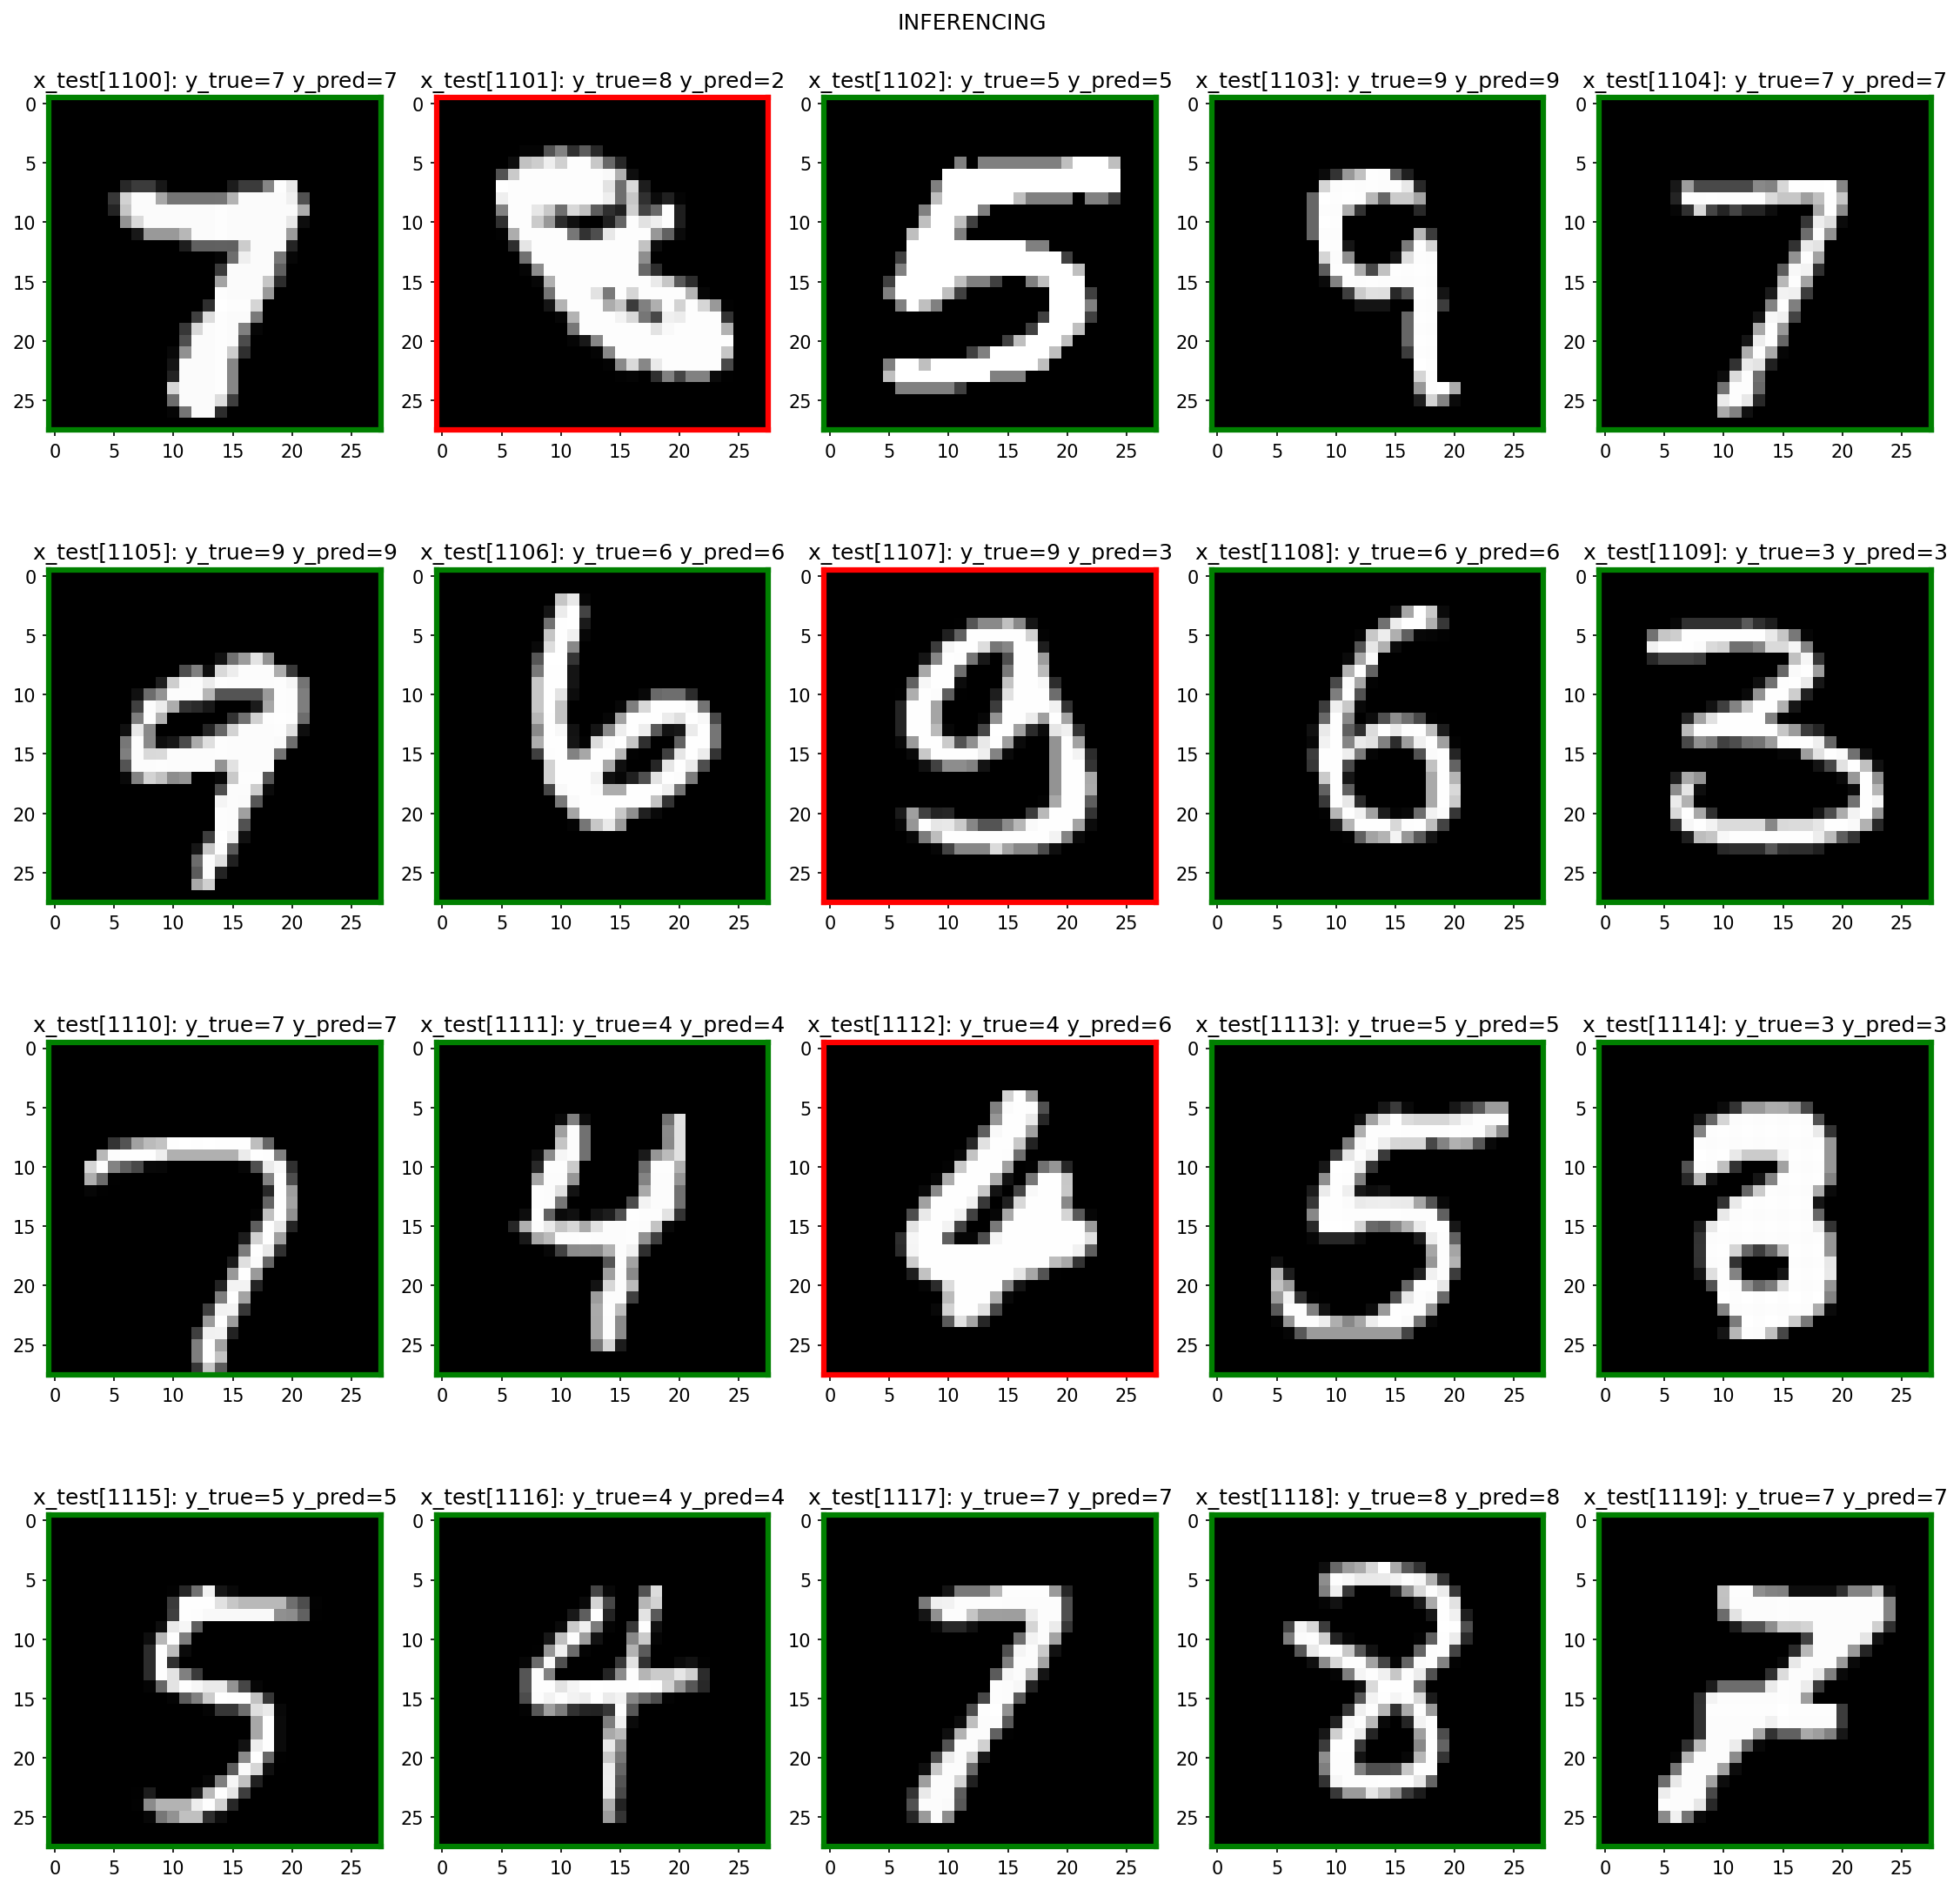

In [13]:
# Test using the model on 20 images

# Prepare a figure with 20 subplots
n_row, n_col = 4, 5
fig, ax = plt.subplots(n_row, n_col, figsize=(15, 15), dpi=150)
fig.suptitle("INFERENCING")

# Predict 20 images (starting from 'first') in a single forward pass
first = 1100
y_preds = model.predict( x_test[ first:(first+20), ... ], verbose=0 )
print( f"y_preds:\n>> Type: {type(y_preds)}\n>> Shape: {y_preds.shape}\n" )

# Visualize the results
for r in range(n_row):
  for c in range(n_col):
    index = (r * n_col) + c + first
    label, pred = y_test[index] , int(np.argmax(y_preds[index-first]))
    ax[r,c].imshow( x_test[index].reshape(28,28), cmap='gray' )
    ax[r,c].set_title( f"x_test[{index}]: y_true={label} y_pred={pred}" )
    if label == pred:
      _ = [ (spine.set_edgecolor('green'),spine.set_linewidth(3)) for spine in ax[r,c].spines.values() ] # Make the plot's frame green
    else:
      _ = [ (spine.set_edgecolor('red'),spine.set_linewidth(3)) for spine in ax[r,c].spines.values() ]   # Make the plot's frame red
fig.tight_layout()